# Pipeline de Poda Estruturada — VGG no CIFAR-10

**Objetivo:** Comparar **Poda Estruturada Local** vs **Poda Estruturada Global** utilizando saliência **L1** e **l2** numa . . .
Este notebook implementa:

1. **Configuração e Importações** — Configuração do dispositivo e monitorização da VRAM.
2. **Poda Estruturada Global** — Classificação e remoção de neurónios em toda a rede com base na sua importância.
3. **Ajuste Fino (*Fine-Tuning*)** — Recuperação iterativa do desempenho após a poda (SGD com Momentum).
4. **Pipeline Automatizado** — Comparação sistemática entre diferentes níveis de esparsidade.
5. **Visualização** — Gráficos comparativos (Precisão, Latência e Taxa de Compressão).


---
## 1. Setup e Importações

Carregamento de todas as dependências, importação das arquiteturas e métricas de `utils.py`, e configuração do dispositivo de computação com tracking inicial de memória VRAM.

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import numpy as np
import random
import copy
import time
from pathlib import Path
from tqdm import tqdm
from torch.utils.data import DataLoader, Subset
import torch_pruning as tp
from torchvision.models import vgg16_bn
import pandas as pd
from IPython.display import display
import re
import seaborn as sns

# ── Importações do utils.py ──
from utils import (
    CIFAR10VGG,
    evaluate_model,
    compute_metrics,
    train_model,
    classes
)

# ── Reprodutibilidade ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Dispositivo (foco em CUDA) ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()
    vram_initial = torch.cuda.memory_allocated(device) / (1024**2)
    print(f"GPU: {torch.cuda.get_device_name(device)}")
    print(f"VRAM alocada inicialmente: {vram_initial:.2f} MB")
else:
    print("AVISO: CUDA não disponível. Os resultados de VRAM serão 0.")

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
VRAM alocada inicialmente: 1543.05 MB


### Carregamento de Dados — Split Determinístico

Para garantir uma comparação justa entre as experiências de poda, reutilizamos o split
determinístico treino/validação gerado durante o treino do baseline.

In [16]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

full_trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

# Reutilizar o split determinístico guardado
split = torch.load("data/cifar10_split.pt", weights_only=False)
train_indices = split["train_indices"]
val_indices = split["val_indices"]

trainset = Subset(full_trainset, train_indices)
valset = Subset(full_trainset, val_indices)

batch_size = 64
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
valloader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train: {len(trainset):,} | Val: {len(valset):,} | Test: {len(testset):,}")

Train: 42,500 | Val: 7,500 | Test: 10,000


### Carregamento do Modelo Baseline

Carregamento do MLP pré-treinado no CIFAR-10. Este modelo serve como ponto de referência
para todas as experiências de poda subsequentes.

In [17]:
models_dir = Path('model_dir')
PATH_VGG = models_dir / 'cifar_vgg.pt'

baseline_model = torch.load(PATH_VGG, weights_only=False)
baseline_model = baseline_model.to(device)
baseline_model.eval()

print(baseline_model)
print(f"\nTotal de parâmetros: {sum(p.numel() for p in baseline_model.parameters()):,}")

if device.type == "cuda":
    vram_model = torch.cuda.memory_allocated(device) / (1024**2)
    print(f"VRAM após carregar modelo: {vram_model:.2f} MB")

CIFAR10VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPo

---
## 2. Funções de Saliência para Estimativa de Importância dos Neurónios

A saliência de cada neurónio é calculada com base na norma dos seus pesos.
Neurónios com menor saliência são considerados menos importantes e são candidatos à remoção.

Para o neurónio $j$ na camada com pesos $W$:

**Norma L1:**  $S_j = \sum_i |w_{ij}|$

**Norma L2:**  $S_j = \sqrt{\sum_i w_{ij}^2}$

In [7]:
class L1Saliency(tp.importance.Importance):
    """
    Custom saliency mapping designed for Torch-Pruning.
    Computes custom L1-norm scaling across both Conv and Linear dimensions.
    """
    def __call__(self, group, **kwargs):
        # group[0] represents the root structural layer of this coupled cluster
        dep, idxs = group[0]
        layer = dep.target 
        
        # Calculate your custom score map per channel/neuron
        if hasattr(layer, 'weight') and layer.weight is not None:
            # Flatten all dimensions except the output channel (dim 0) 
            # and extract your custom metric
            reduce_dims = list(range(1, layer.weight.dim()))
            saliency = torch.norm(layer.weight.data, p=1, dim=reduce_dims)
            return saliency
            
        # Fallback matrix if the module lacks learnable weights
        return torch.zeros(len(idxs), device=layer.weight.device)

In [8]:
class L2Saliency(tp.importance.Importance):
    """
    Saliência baseada na Norma L2 dos pesos.
    Calcula a raiz do somatório dos quadrados dos pesos associados a cada canal/neurónio.
    """
    def __call__(self, group, **kwargs):
        dep, idxs = group[0]
        layer = dep.target 
        
        if hasattr(layer, 'weight') and layer.weight is not None:
            # Planificar todas as dimensões exceto a dimensão de saída (canais/neurónios)
            reduce_dims = list(range(1, layer.weight.dim()))
            saliency = torch.norm(layer.weight.data, p=2, dim=reduce_dims)
            return saliency
            
        return torch.zeros(len(idxs), device=layer.weight.device)

In [9]:
class TaylorSaliency(tp.importance.Importance):
    """
    Saliência baseada na Aproximação de Taylor de 1ª Ordem.
    Mede a sensibilidade da perda à remoção do canal usando o produto escalar: |peso * gradiente|.
    """
    def __call__(self, group, **kwargs):
        dep, idxs = group[0]
        layer = dep.target 
        
        if hasattr(layer, 'weight') and layer.weight is not None:
            if layer.weight.grad is None:
                # Fallback amigável caso nenhum backward tenha sido executado
                return torch.zeros(layer.weight.shape[0], device=layer.weight.device)
                
            reduce_dims = list(range(1, layer.weight.dim()))
            # Cálculo de Taylor de Primeira Ordem: |W * dL/dW|
            taylor_values = torch.abs(layer.weight.data * layer.weight.grad.data)
            saliency = taylor_values.sum(dim=reduce_dims)
            return saliency
            
        return torch.zeros(len(idxs), device=layer.weight.device)

### Loop de Experimentação

Compara sistematicamente:
- **Tipo de Poda:** Local L1 vs Global L1
- **Sparsity Ratios:** 10%, 20%, 30%, 50%, 70%

Para cada iteração executa: Poda → Fine-Tuning → Avaliação completa.

In [18]:
# Configuração de Diretórios
save_dir = Path('modelos_podados_vgg')
save_dir.mkdir(parents=True, exist_ok=True)

# Definição dos Hiperparâmetros
sparsity_ratios = [0.10, 0.20, 0.30, 0.50, 0.70]
fine_tune_epochs = 5
fine_tune_lr = 1e-4
criterion = nn.CrossEntropyLoss()
estrategias = ["one-shot", "iterative"]
skip_if_exists = True

# Mapeamento de Métodos compatíveis com o Torch-Pruning
pruning_methods = {
    # p=1 significa Norma L1, p=2 significa Norma L2
    "Local L1 (Magnitude)":   {"importance": tp.importance.MagnitudeImportance(p=1), "global": False},
    "Local L2 (Magnitude)":   {"importance": tp.importance.MagnitudeImportance(p=2), "global": False},
    "Local Taylor (Gradiente)": {"importance": tp.importance.TaylorImportance(),        "global": False},
    
    "Global L1 (Magnitude)":  {"importance": tp.importance.MagnitudeImportance(p=1), "global": True},
    "Global L2 (Magnitude)":  {"importance": tp.importance.MagnitudeImportance(p=2), "global": True},
    "Global Taylor (Gradiente)": {"importance": tp.importance.TaylorImportance(),        "global": True}
}

example_inputs = torch.randn(1, 3, 32, 32).to(device)

# --- 1. Avaliação do Baseline de Referência ---
print("=" * 70)
print("AVALIAÇÃO DO MODELO VGG BASELINE")
print("=" * 70)

y_true_baseline, y_pred_baseline, baseline_results = evaluate_model(baseline_model, testloader, criterion, device=device)
baseline_results['param_count'] = sum(p.numel() for p in baseline_model.parameters())

print(f"  Accuracy:   {baseline_results['accuracy']:.4f}")
print(f"  Parâmetros: {baseline_results['param_count']:,}") 
print(f"  Latência:   {baseline_results['latency'] / 1000:.4f} s")

all_results = {}
total_experiencias = len(pruning_methods) * len(estrategias) * len(sparsity_ratios)
contador = 1

# --- 2. Loop Principal de Experiências ---
for method_name, config in pruning_methods.items():
    for estrategia in estrategias:
        full_method_key = f"{method_name} ({estrategia})"
        
        print(f"\n{'=' * 70}")
        print(f"MÉTODO: {full_method_key}")
        print(f"{'=' * 70}")
        
        method_results = []

        for ratio in sparsity_ratios:
            # VERIFICAÇÃO DE EXISTÊNCIA (Antecipada)
            partes_nome = method_name.split(" ")
            escopo = partes_nome[0]  # Local ou Global
            norma = partes_nome[1]   # L1, L2 ou Taylor
            
            pasta_especifica = save_dir / escopo / norma
            model_filename = f"VGG_{estrategia}_{int(ratio*100)}pct.pt"
            model_path = pasta_especifica / model_filename
            
            print(f"\n{'─' * 55}")
            print(f"  [{contador}/{total_experiencias}] Sparsity Ratio Alvo: {ratio*100:.0f}%")
            print(f"{'─' * 55}")
            contador += 1
            
            # Se a flag estiver ativa e o modelo já existir, salta diretamente para o próximo rácio
            if skip_if_exists and model_path.exists():
                print(f"  [Ignorado] O ficheiro completo já existe em: {model_path}. A passar à frente...")
                continue
        
            pruned = copy.deepcopy(baseline_model)
            
            # Filtra a camada final para não estragar a dimensionalidade do CIFAR-10 (10 classes)
            ignored_layers = []
            for module in baseline_model.modules():
                if isinstance(module, nn.Linear) and module.out_features == 10:
                    ignored_layers.append(module)
            

            # ─────────────────────────────────────────────────────────
            # ESTRATÉGIA: ONE-SHOT
            # ─────────────────────────────────────────────────────────
            if estrategia == "one-shot":
                print(f"  [One-Shot] A aplicar poda estruturada de {ratio*100:.0f}%...")
                
                if "Taylor" in method_name:
                    pruned.train()
                    pruned.zero_grad()
                    images, labels = next(iter(trainloader))
                    images, labels = images.to(device), labels.to(device)
                    outputs = pruned(images)
                    loss = criterion(outputs, labels)
                    loss.backward()
                
                pruner = tp.pruner.MetaPruner(
                    pruned,
                    example_inputs=example_inputs,
                    importance=config["importance"],
                    global_pruning=config["global"],
                    pruning_ratio=ratio,
                    ignored_layers=ignored_layers,
                )
                pruner.step() 
                
                _, _, pre_ft = evaluate_model(pruned, testloader, criterion, device=device)
                pre_ft['param_count'] = sum(p.numel() for p in pruned.parameters())
                print(f"    Pré-FT  → Acc: {pre_ft['accuracy']:.4f} | Params: {pre_ft['param_count']:,}")
                
                # Correção do unpacking aplicada aqui
                pruned, _, _, _ = train_model(
                    pruned, trainloader, valloader, 
                    epochs=fine_tune_epochs, lr=fine_tune_lr, device=device
                )
                
            # ─────────────────────────────────────────────────────────
            # ESTRATÉGIA: ITERATIVE
            # ─────────────────────────────────────────────────────────
            elif estrategia == "iterative":
                print(f"  [Iterative] A iniciar ciclos de poda estruturada progressiva...")
                num_steps = 3  
                absolute_step_chunk = ratio / num_steps
                pre_ft = None
                
                for step in range(num_steps):
                    pct_remaining_before_cut = 1.0 - (step * absolute_step_chunk)
                    current_step_ratio = absolute_step_chunk / pct_remaining_before_cut
                    
                    print(f"\n    -> Passo {step+1}/{num_steps} (A cortar +{absolute_step_chunk*100:.1f}% do total original)")
                    
                    if "Taylor" in method_name:
                        pruned.train()
                        pruned.zero_grad()
                        images, labels = next(iter(trainloader))
                        images, labels = images.to(device), labels.to(device)
                        outputs = pruned(images)
                        loss = criterion(outputs, labels)
                        loss.backward()
                        
                    pruner = tp.pruner.MetaPruner(
                        pruned,
                        example_inputs=example_inputs,
                        importance=config["importance"],
                        global_pruning=config["global"],
                        pruning_ratio=current_step_ratio,
                        ignored_layers=ignored_layers,
                    )
                    pruner.step()
                    
                    if step == 0:
                        _, _, pre_ft = evaluate_model(pruned, testloader, criterion, device=device)
                        pre_ft['param_count'] = sum(p.numel() for p in pruned.parameters())
                        print(f"    Pré-FT Inicial → Acc: {pre_ft['accuracy']:.4f} | Params: {pre_ft['param_count']:,}")
                    
                    is_last_step = (step == num_steps - 1)
                    step_epochs = fine_tune_epochs if is_last_step else max(1, fine_tune_epochs // 2)
                    
                    # Correção do unpacking aplicada aqui
                    pruned, _, _, _ = train_model(
                        pruned, trainloader, valloader, 
                        epochs=step_epochs, lr=fine_tune_lr, device=device
                    )
                
                # ── 3. Avaliação Final, Métricas e Salvaguarda do Checkpoint ──
                _, y_pred_final, post_ft = evaluate_model(pruned, testloader, criterion, device=device)
                post_ft['param_count'] = sum(p.numel() for p in pruned.parameters())
                
                print(f"\n  Pós-FT Final → Acc: {post_ft['accuracy']:.4f} | "
                    f"Params: {post_ft['param_count']:,} | "
                    f"Latência: {post_ft['latency'] / 1000:.4f}s")
                
                method_results.append({
                    "sparsity_ratio": ratio,
                    "pre_finetune": pre_ft,
                    "post_finetune": post_ft,
                })
                
                pasta_especifica = save_dir / escopo / norma
                pasta_especifica.mkdir(parents=True, exist_ok=True)
                
                # Salvaguarda Unificada (Modelo + Métricas + Previsões)
                conteudo_checkpoint = {
                    "model": pruned,               
                    "metrics": post_ft,            
                    "y_pred": y_pred_final         
                }
                torch.save(conteudo_checkpoint, model_path)
                print(f"  [Sucesso] Ficheiro completo guardado em: {model_path}")
                
                del pruned
                if device.type == "cuda":
                    torch.cuda.empty_cache()
                
        all_results[full_method_key] = method_results

print(f"\n{'=' * 70}\n PIPELINE EXPERIMENTAL CONCLUÍDO PARA A VGG\n{'=' * 70}")

AVALIAÇÃO DO MODELO VGG BASELINE
  Accuracy:   0.7852
  Parâmetros: 9,493,770
  Latência:   8.4528 s

MÉTODO: Local L1 (Magnitude) (one-shot)

───────────────────────────────────────────────────────
  [1/60] Sparsity Ratio Alvo: 10%
───────────────────────────────────────────────────────
  [Ignorado] O ficheiro completo já existe em: modelos_podados_vgg\Local\L1\VGG_one-shot_10pct.pt. A passar à frente...

───────────────────────────────────────────────────────
  [2/60] Sparsity Ratio Alvo: 20%
───────────────────────────────────────────────────────
  [Ignorado] O ficheiro completo já existe em: modelos_podados_vgg\Local\L1\VGG_one-shot_20pct.pt. A passar à frente...

───────────────────────────────────────────────────────
  [3/60] Sparsity Ratio Alvo: 30%
───────────────────────────────────────────────────────
  [Ignorado] O ficheiro completo já existe em: modelos_podados_vgg\Local\L1\VGG_one-shot_30pct.pt. A passar à frente...

───────────────────────────────────────────────────────


### Tabela Resumo dos Resultados

In [21]:
# Caminho base onde os modelos foram guardados
save_dir = Path('modelos_podados_vgg')

# Preparar a lista de dicionários para o DataFrame
tabela_dados = []

# 1. Extrair métricas do Baseline (caso a variável exista em memória nesta sessão)
if 'baseline_results' in locals() or 'baseline_results' in globals():
    baseline_params = baseline_results.get('param_count', 1)
    # utils.py calcula a latência em milissegundos, convertemos para segundos (s)
    baseline_lat_s = baseline_results.get('latency', 0) / 1000 
    
    tabela_dados.append({
        "Método": "Baseline",
        "Sparsity (%)": 0,
        "Parâmetros": baseline_params,
        "Compressão (x)": 1.00,
        "Accuracy": round(baseline_results.get('accuracy', 0), 4),
        "Loss": round(baseline_results.get('loss', 0), 4) if 'loss' in baseline_results else None,
        "Bal. Acc": round(baseline_results.get('balanced_accuracy', 0), 4),
        "Prec (Macro)": round(baseline_results.get('precision_macro', 0), 4),
        "Prec (Weighted)": round(baseline_results.get('precision_weighted', 0), 4),
        "Rec (Macro)": round(baseline_results.get('recall_macro', 0), 4),
        "Rec (Weighted)": round(baseline_results.get('recall_weighted', 0), 4),
        "F1 (Macro)": round(baseline_results.get('f1_macro', 0), 4),
        "F1 (Weighted)": round(baseline_results.get('f1_weighted', 0), 4),
        "Cohen Kappa": round(baseline_results.get('cohen_kappa', 0), 4),
        "MCC": round(baseline_results.get('mcc', 0), 4),
        "Latência (s)": round(baseline_lat_s, 4),
        "VRAM (MB)": round(baseline_results.get('vram', 0), 2)
    })
else:
    baseline_params = None
    print("Aviso: 'baseline_results' não foi encontrado na sessão atual. A linha do Baseline foi omitida.")

# 2. Procurar dinamicamente todos os ficheiros de checkpoint (.pt) nas subpastas
checkpoint_files = sorted(list(save_dir.glob('**/*.pt')))

for model_path in checkpoint_files:
    try:
        # Carregar o checkpoint na CPU para poupar VRAM durante a leitura das métricas
        checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
        post = checkpoint.get('metrics', {})
        
        # Reconstruir os metadados a partir da estrutura de caminhos:
        # Caminho tipo: modelos_podados_vgg / <escopo> / <norma> / VGG_<estrategia>_<ratio>pct.pt
        escopo = model_path.parent.parent.name  # Ex: Local ou Global
        norma = model_path.parent.name          # Ex: L1, L2 ou Taylor
        stem = model_path.stem                  # Ex: VGG_one-shot_10pct
        
        # Expressão regular para capturar a estratégia e a percentagem de sparsity
        match = re.match(r"VGG_(.+)_(\d+)pct", stem)
        if match:
            estrategia = match.group(1)
            sparsity_pct = int(match.group(2))
        else:
            continue  # Salta ficheiros que não correspondam ao padrão esperado
            
        # Formatar o nome do método exatamente igual ao pipeline original
        sufixo = "(Gradiente)" if "Taylor" in norma else "(Magnitude)"
        full_method_name = f"{escopo} {norma} {sufixo} ({estrategia})"
        
        # Calcular taxa de compressão baseada nos parâmetros guardados
        post_params = post.get('param_count', 1)
        compression = (baseline_params / max(post_params, 1)) if baseline_params else None
        
        # Converter latência (ms -> segundos)
        post_lat_s = post.get('latency', 0) / 1000
        
        # Mapear todas as métricas detalhadas do utils.py
        tabela_dados.append({
            "Método": full_method_name,
            "Sparsity (%)": sparsity_pct,
            "Parâmetros": post_params,
            "Compressão (x)": round(compression, 2) if compression else None,
            "Accuracy": round(post.get('accuracy', 0), 4),
            "Loss": round(post.get('loss', 0), 4) if 'loss' in post else None,
            "Bal. Acc": round(post.get('balanced_accuracy', 0), 4),
            "Prec (Macro)": round(post.get('precision_macro', 0), 4),
            "Prec (Weighted)": round(post.get('precision_weighted', 0), 4),
            "Rec (Macro)": round(post.get('recall_macro', 0), 4),
            "Rec (Weighted)": round(post.get('recall_weighted', 0), 4),
            "F1 (Macro)": round(post.get('f1_macro', 0), 4),
            "F1 (Weighted)": round(post.get('f1_weighted', 0), 4),
            "Cohen Kappa": round(post.get('cohen_kappa', 0), 4),
            "MCC": round(post.get('mcc', 0), 4),
            "Latência (s)": round(post_lat_s, 4),
            "VRAM (MB)": round(post.get('vram', 0), 2)
        })
    except Exception as e:
        print(f"Erro ao ler o checkpoint {model_path}: {e}")

# Criar o DataFrame principal
df_resultados = pd.DataFrame(tabela_dados)

# Ordenar as colunas de forma lógica para uma leitura fluida da tabela
colunas_ordenadas = [
    "Método", "Sparsity (%)", "Parâmetros", "Compressão (x)", "Accuracy", "Loss", 
    "Bal. Acc", "Prec (Macro)", "Prec (Weighted)", "Rec (Macro)", "Rec (Weighted)", "F1 (Macro)", "F1 (Weighted)",  
    "Cohen Kappa", "MCC", "Latência (s)", "VRAM (MB)"
]
# Garante que só organiza as colunas que realmente foram preenchidas no DataFrame
colunas_existentes = [col for col in colunas_ordenadas if col in df_resultados.columns]
df_resultados = df_resultados[colunas_existentes]

# Aplicar estilos visuais e destacar os melhores desempenhos por coluna
estilo_tabela = df_resultados.style.set_properties(**{'text-align': 'center'}) \
    .set_table_styles([dict(selector='th', props=[('text-align', 'center')])]) \
    .highlight_max(subset=['Accuracy', 'Bal. Acc', 'F1 (Macro)', 'MCC', 'Compressão (x)'], color='lightgreen') \
    .highlight_min(subset=['Latência (s)', 'Loss'], color='lightgreen')

display(estilo_tabela)

,Método,Sparsity (%),Parâmetros,Compressão (x),Accuracy,Loss,Bal. Acc,Prec (Macro),Prec (Weighted),Rec (Macro),Rec (Weighted),F1 (Macro),F1 (Weighted),Cohen Kappa,MCC,Latência (s),VRAM (MB)
0,Baseline,0,9493770,1.000000,0.785200,1.062200,0.785200,0.790600,0.790600,0.785200,0.785200,0.783800,0.783800,0.761300,0.762300,8.452800,1576.850000
1,Global L1 (Magnitude) (iterative),10,7951034,1.190000,0.784600,1.100700,0.784600,0.796300,0.796300,0.784600,0.784600,0.786700,0.786700,0.760700,0.761500,8.278700,2944.870000
2,Global L1 (Magnitude) (iterative),20,6253839,1.520000,0.789400,1.012800,0.789400,0.792800,0.792800,0.789400,0.789400,0.789100,0.789100,0.766000,0.766500,8.172700,3154.540000
3,Global L1 (Magnitude) (iterative),30,4830595,1.970000,0.791500,1.015800,0.791500,0.800100,0.800100,0.791500,0.791500,0.792700,0.792700,0.768300,0.769100,8.138100,3252.000000
4,Global L1 (Magnitude) (iterative),50,2467507,3.850000,0.774300,1.061600,0.774300,0.776800,0.776800,0.774300,0.774300,0.773800,0.773800,0.749200,0.749600,8.153100,3279.390000
5,Global L1 (Magnitude) (iterative),70,851800,11.150000,0.728100,1.080900,0.728100,0.744100,0.744100,0.728100,0.728100,0.733400,0.733400,0.697900,0.698600,7.994400,3300.350000
6,Global L1 (Magnitude) (one-shot),10,7794232,1.220000,0.794800,0.950300,0.794800,0.795900,0.795900,0.794800,0.794800,0.793200,0.793200,0.772000,0.772500,8.330700,2547.140000
7,Global L1 (Magnitude) (one-shot),20,6086504,1.560000,0.769600,1.077200,0.769600,0.781400,0.781400,0.769600,0.769600,0.768000,0.768000,0.744000,0.745400,8.167900,2631.090000
8,Global L1 (Magnitude) (one-shot),30,4650268,2.040000,0.795300,0.893600,0.795300,0.796500,0.796500,0.795300,0.795300,0.794600,0.794600,0.772600,0.772900,8.132000,2705.420000
9,Global L1 (Magnitude) (one-shot),50,2311651,4.110000,0.763400,1.089100,0.763400,0.791400,0.791400,0.763400,0.763400,0.769100,0.769100,0.737100,0.739800,8.084800,2761.840000


---
## 5. Avaliação Global e Visualização

Gráficos comparativos dos resultados experimentais:
1. **Sparsity Ratio vs. Test Accuracy** — Comparação da degradação de exatidão
2. **Sparsity Ratio vs. Inference Latency** — Redução de latência
3. **Compressão de Parâmetros vs. Speedup** — Eficiência da compressão

O Gráfico de Trade-off (Curva de Decaimento)

A melhor forma de ver estes dados é um gráfico onde o eixo X é o Rácio de Sparsity (o quanto cortámos) e o eixo Y é a Accuracy. Isto permite-te ver instantaneamente qual o método que aguenta mais poda sem perder qualidade.

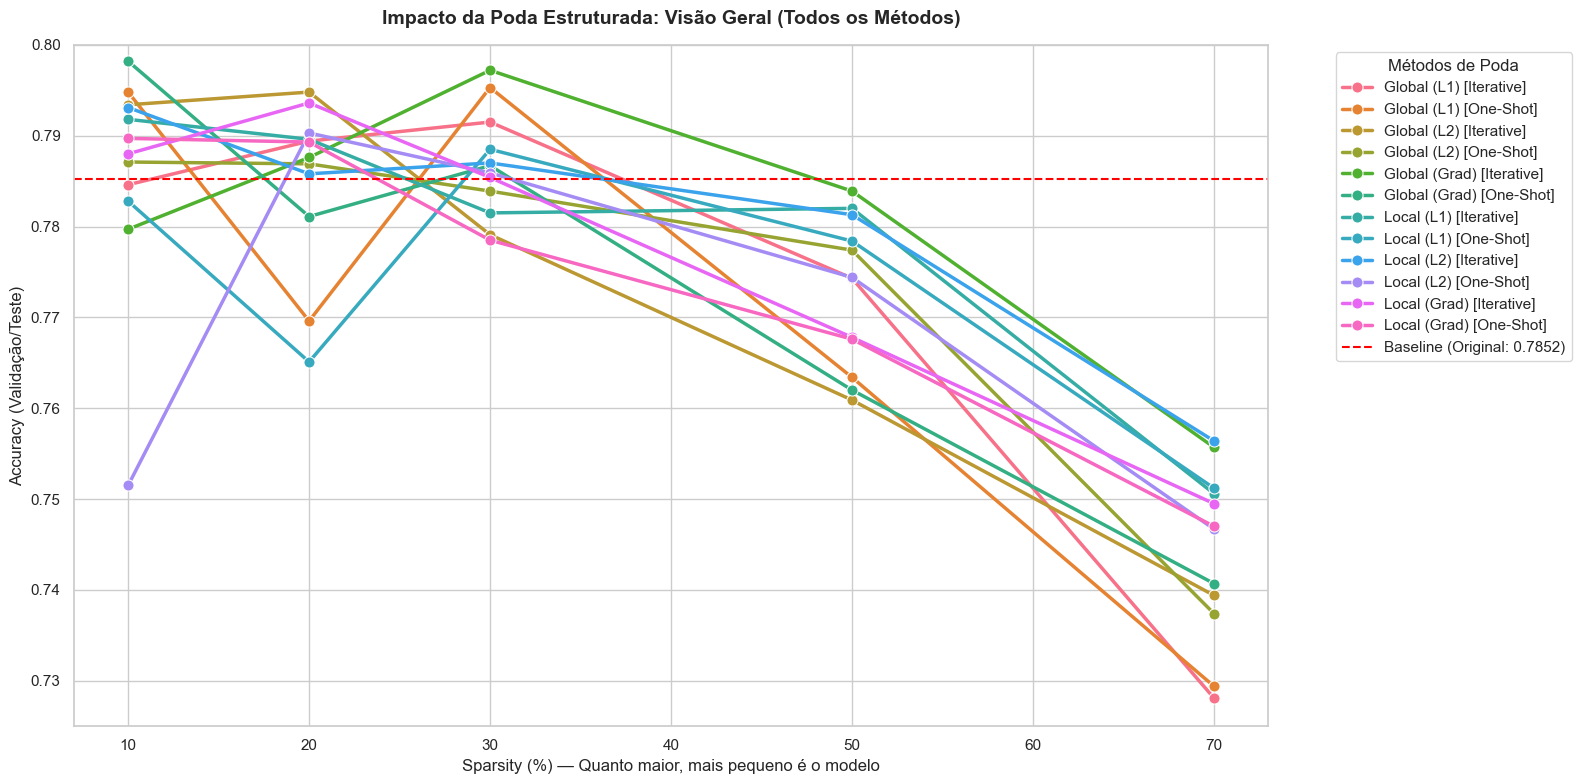


DESDOBRAMENTO DAS ANÁLISES ESPECÍFICAS (COM DISTINÇÃO DE TRAÇADO)


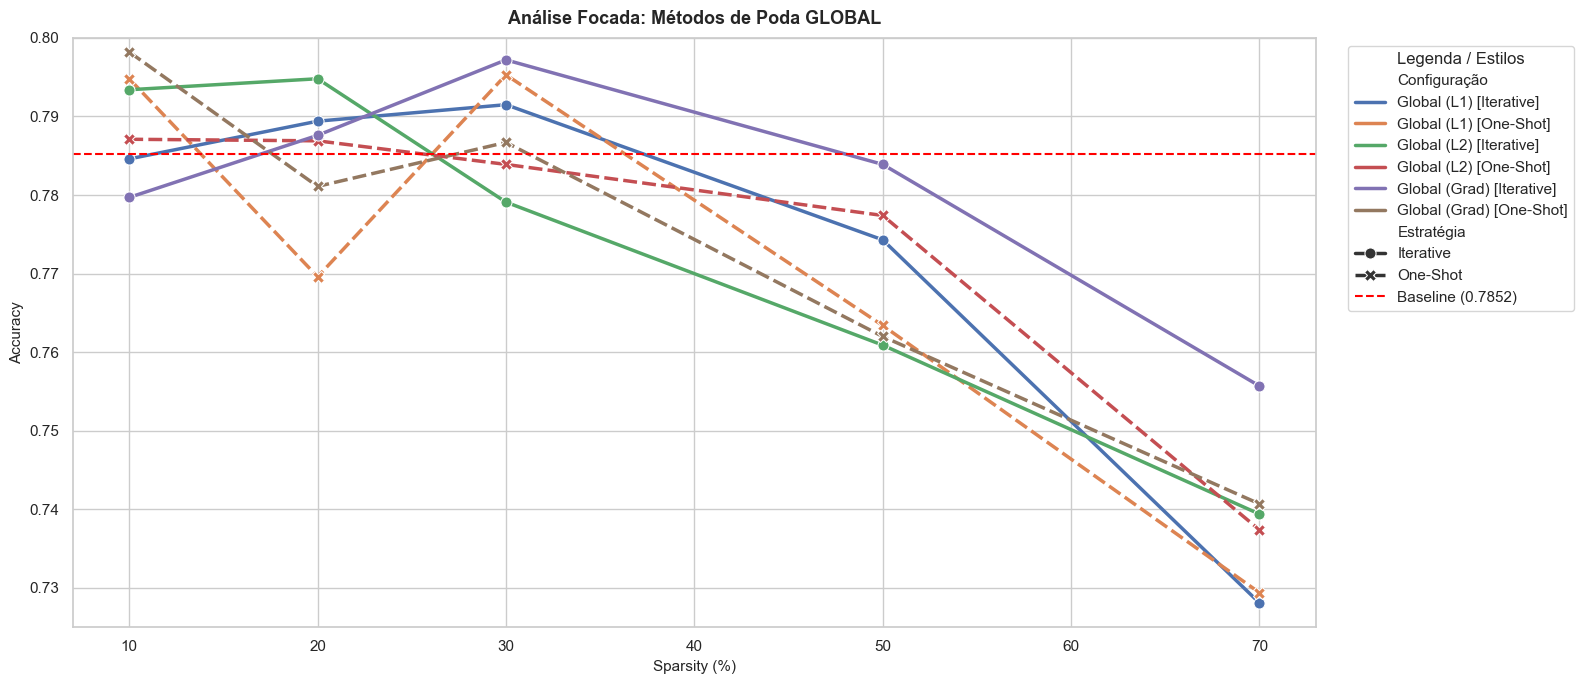

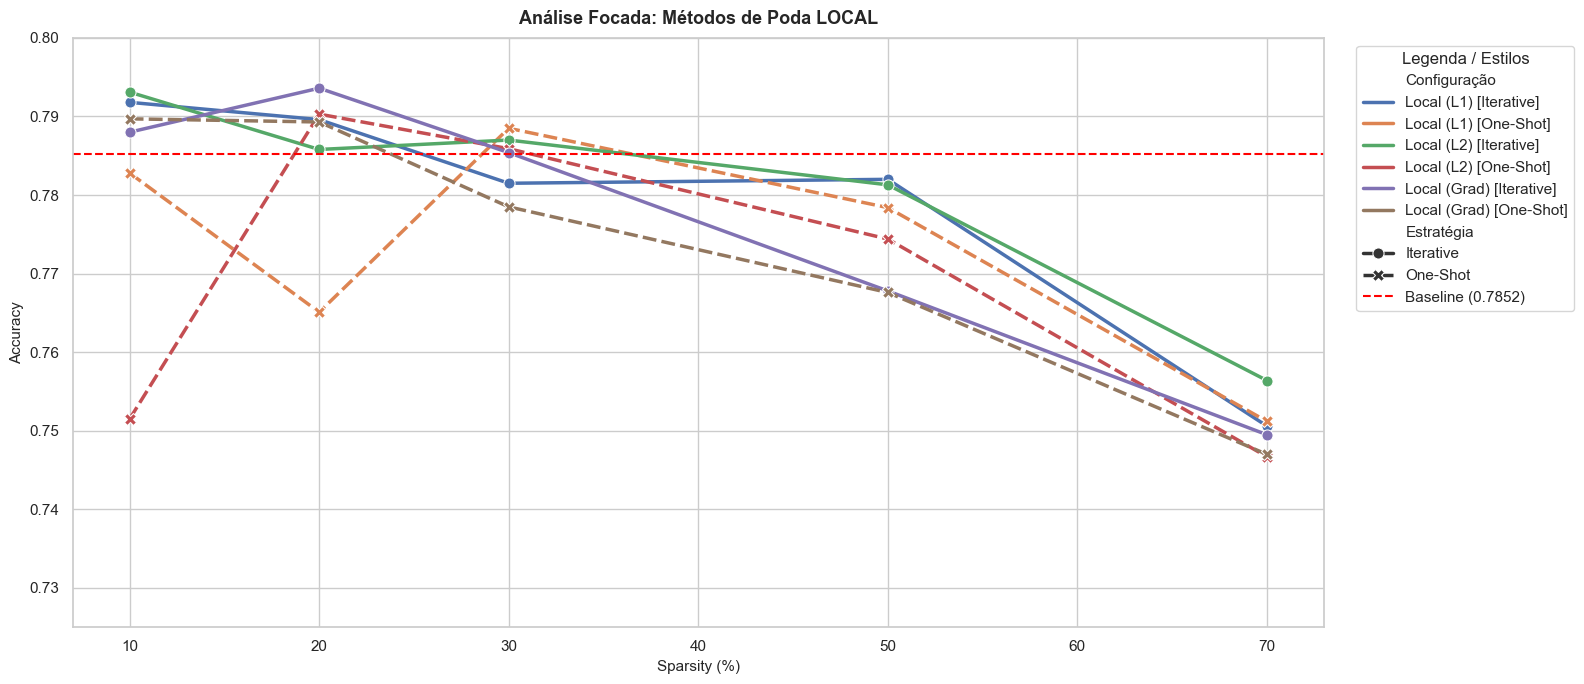

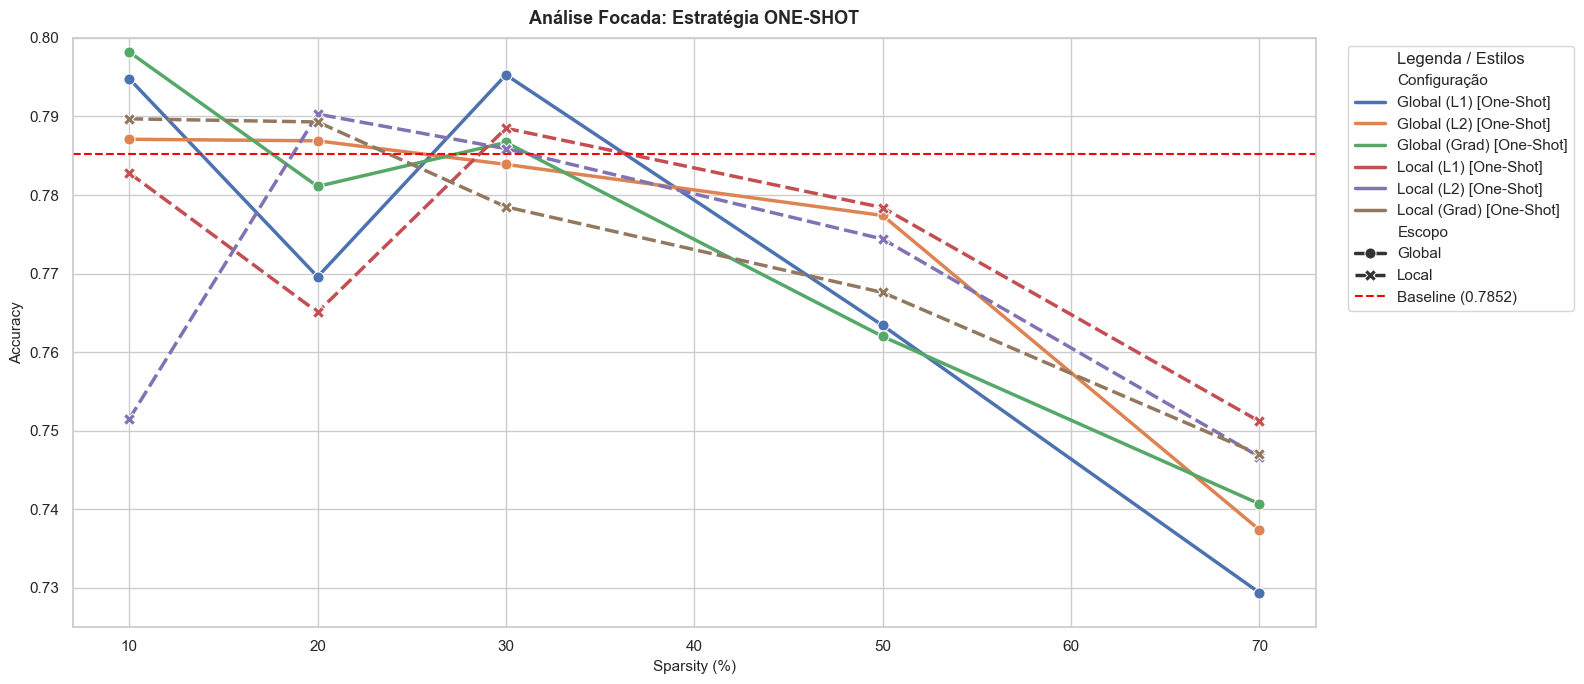

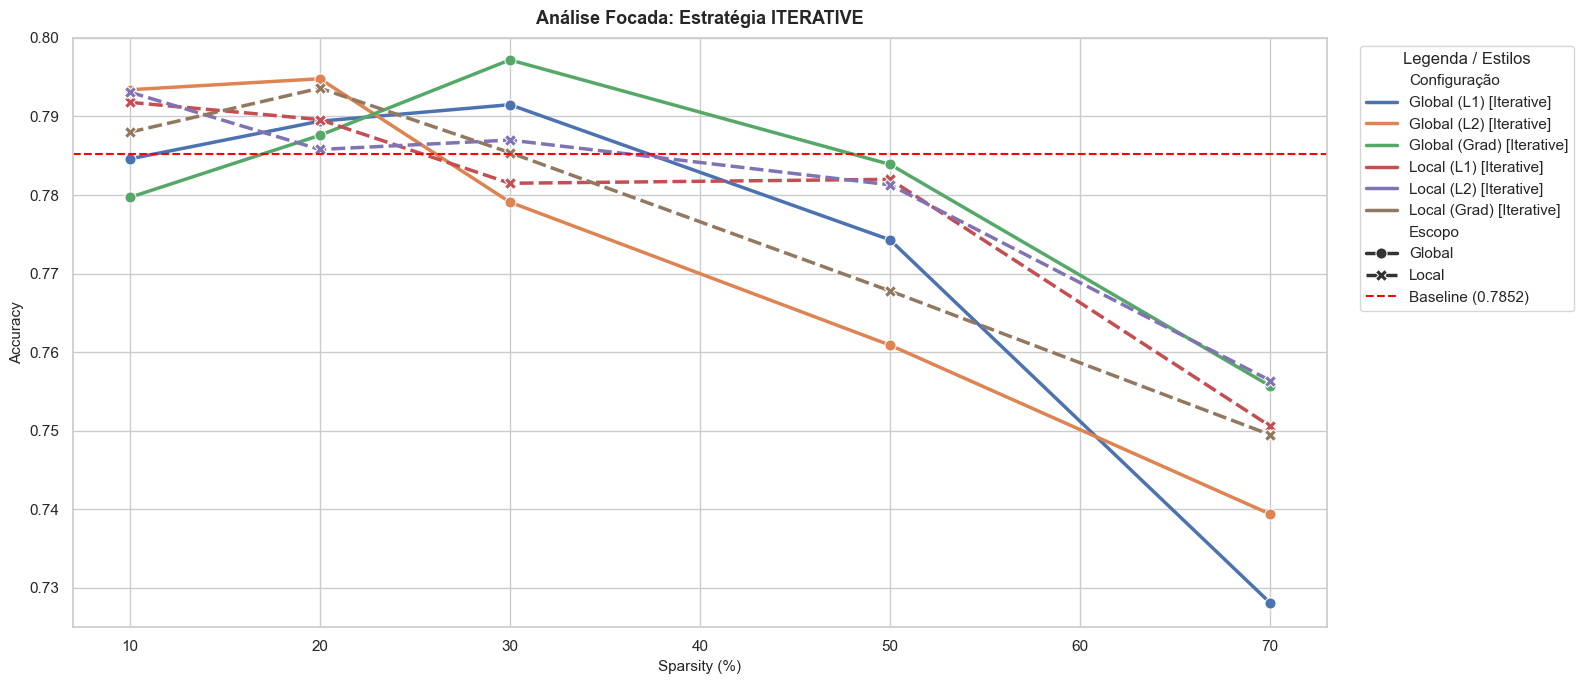

In [42]:
# 1. Recolha rápida dos dados dos checkpoints
save_dir = Path('modelos_podados_vgg')
dados_grafico = []

# Guardar a precisão do baseline se existir
baseline_acc = baseline_results.get('accuracy', 0) if 'baseline_results' in locals() or 'baseline_results' in globals() else None

checkpoint_files = sorted(list(save_dir.glob('**/*.pt')))
for model_path in checkpoint_files:
    try:
        checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
        post = checkpoint.get('metrics', {})
        
        escopo = model_path.parent.parent.name     # Ex: Global ou Local
        norma = model_path.parent.name             # Ex: L1, L2 ou Taylor
        stem = model_path.stem                     # Ex: VGG_one-shot_10pct
        
        match = re.match(r"VGG_(.+)_(\d+)pct", stem)
        if match:
            estrategia = match.group(1)            # Ex: one-shot ou iterative
            sparsity_pct = int(match.group(2))
            
            # Formatação para capitular os nomes e deixar a legenda bonita
            estrategia_formatada = "One-Shot" if estrategia.lower() == "one-shot" else "Iterative"
            escopo_formatado = "Global" if escopo.lower() == "global" else "Local"
            
            sufixo = "(Grad)" if "Taylor" in norma else f"({norma})"
            config_name = f"{escopo_formatado} {sufixo} [{estrategia_formatada}]"
            
            dados_grafico.append({
                "Configuração": config_name,
                "Escopo": escopo_formatado,
                "Estratégia": estrategia_formatada,
                "Sparsity (%)": sparsity_pct,
                "Accuracy": post.get('accuracy', 0),
                "Compressão (x)": baseline_results['param_count'] / post['param_count'] if baseline_acc else 1
            })
    except Exception:
        continue

df_plot = pd.DataFrame(dados_grafico)

# ==============================================================================
# GRÁFICO 1: VISÃO GERAL (TODOS OS MÉTODOS)
# ==============================================================================
plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=df_plot, 
    x="Sparsity (%)", 
    y="Accuracy", 
    hue="Configuração", 
    marker="o", 
    linewidth=2.5,
    markersize=8
)

if baseline_acc:
    plt.axhline(y=baseline_acc, color='red', linestyle='--', linewidth=1.5, label=f'Baseline (Original: {baseline_acc:.4f})')

plt.title("Impacto da Poda Estruturada: Visão Geral (Todos os Métodos)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Sparsity (%) — Quanto maior, mais pequeno é o modelo", fontsize=12)
plt.ylabel("Accuracy (Validação/Teste)", fontsize=12)
plt.ylim(0.725, 0.80) 
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Métodos de Poda")
plt.tight_layout()
plt.show()


# ==============================================================================
# GRÁFICOS ANALÍTICOS COM DISTINÇÃO DE TIPO DE LINHA (DASHES)
# ==============================================================================
# Adicionámos a chave "coluna_estilo" para ditar o que define o tipo de linha em cada gráfico
analises_especificas = [
    {
        "titulo": "Análise Focada: Métodos de Poda GLOBAL", 
        "coluna_filtro": "Escopo", "valor_filtro": "Global", 
        "coluna_estilo": "Estratégia"  # Linha contínua vs tracejada diferencia One-Shot/Iterative
    },
    {
        "titulo": "Análise Focada: Métodos de Poda LOCAL", 
        "coluna_filtro": "Escopo", "valor_filtro": "Local", 
        "coluna_estilo": "Estratégia"  # Linha contínua vs tracejada diferencia One-Shot/Iterative
    },
    {
        "titulo": "Análise Focada: Estratégia ONE-SHOT", 
        "coluna_filtro": "Estratégia", "valor_filtro": "One-Shot", 
        "coluna_estilo": "Escopo"      # Linha contínua vs tracejada diferencia Global/Local
    },
    {
        "titulo": "Análise Focada: Estratégia ITERATIVE", 
        "coluna_filtro": "Estratégia", "valor_filtro": "Iterative", 
        "coluna_estilo": "Escopo"      # Linha contínua vs tracejada diferencia Global/Local
    }
]

print(f"\n{'='*80}\nDESDOBRAMENTO DAS ANÁLISES ESPECÍFICAS (COM DISTINÇÃO DE TRAÇADO)\n{'='*80}")

for analise in analises_especificas:
    # Filtrar o dataframe para a categoria atual
    df_sub = df_plot[df_plot[analise["coluna_filtro"]] == analise["valor_filtro"]]
    
    if df_sub.empty:
        print(f"\n[Aviso] Sem dados disponíveis para renderizar: {analise['titulo']}")
        continue
        
    plt.figure(figsize=(16, 7))
    
    # O truque está no parâmetro 'style' combinado com o 'hue'
    sns.lineplot(
        data=df_sub, 
        x="Sparsity (%)", 
        y="Accuracy", 
        hue="Configuração", 
        style=analise["coluna_estilo"],  # <--- Aplica estilos de linha diferentes dinamicamente
        markers=True,                    # <--- Faz com que os marcadores também mudem de formato para ajudar daltónicos
        linewidth=2.5,
        markersize=8
    )
    
    # Linha de referência do Baseline
    if baseline_acc:
        plt.axhline(y=baseline_acc, color='red', linestyle='--', linewidth=1.5, label=f'Baseline ({baseline_acc:.4f})')
        
    plt.title(analise["titulo"], fontsize=13, fontweight='bold', pad=10)
    plt.xlabel("Sparsity (%)", fontsize=11)
    plt.ylabel("Accuracy", fontsize=11)
    plt.ylim(0.725, 0.80) 
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Legenda / Estilos")
    plt.tight_layout()
    plt.show()

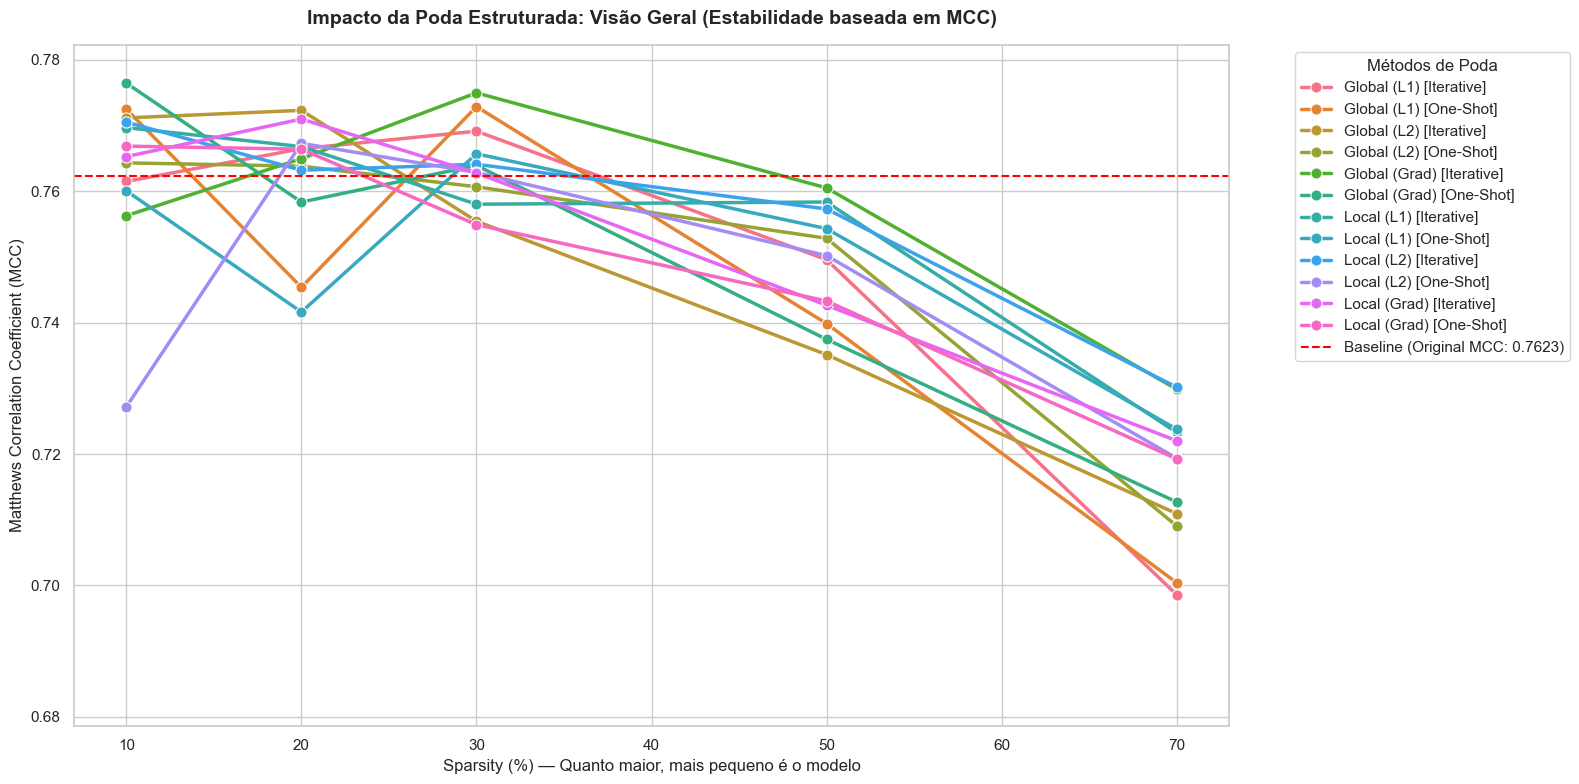


DESDOBRAMENTO DAS ANÁLISES ESPECÍFICAS (EIXO Y: MCC)


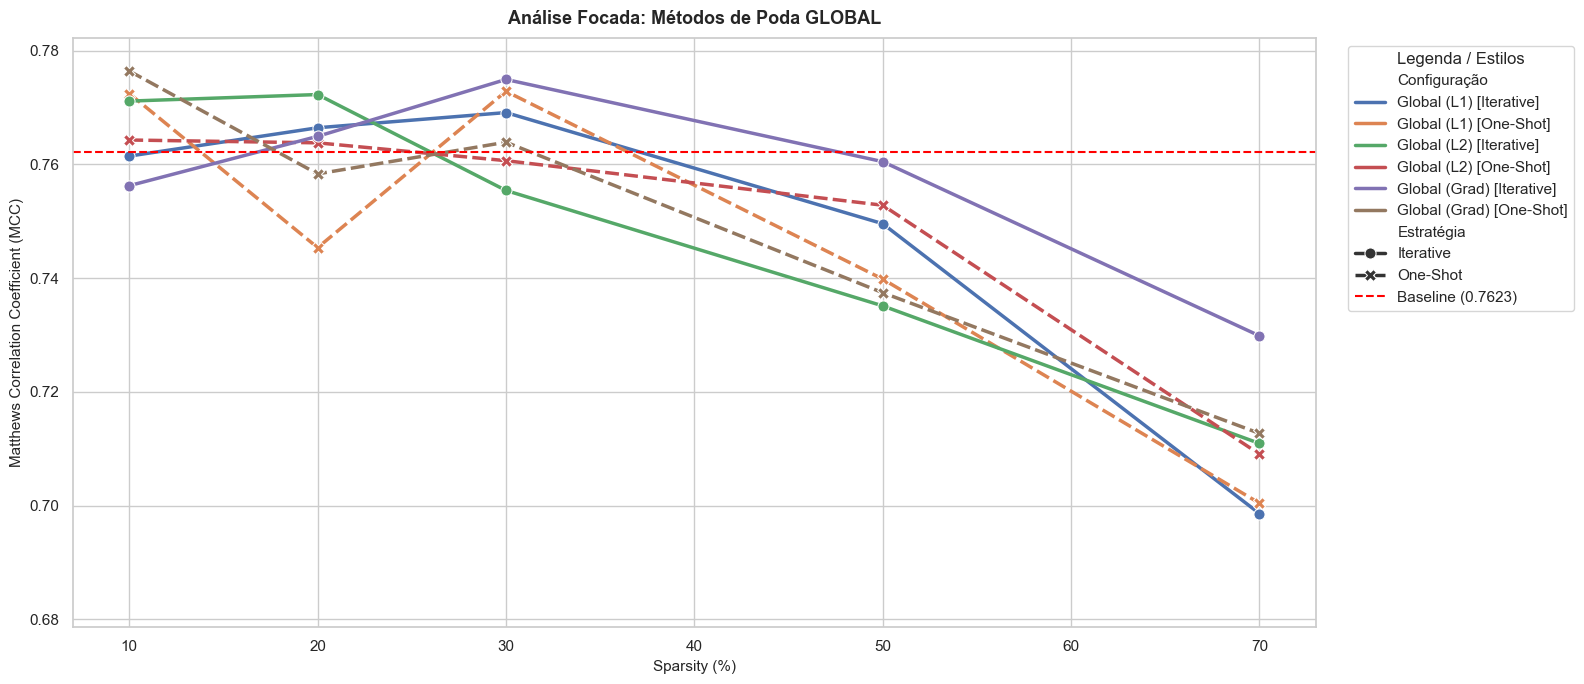

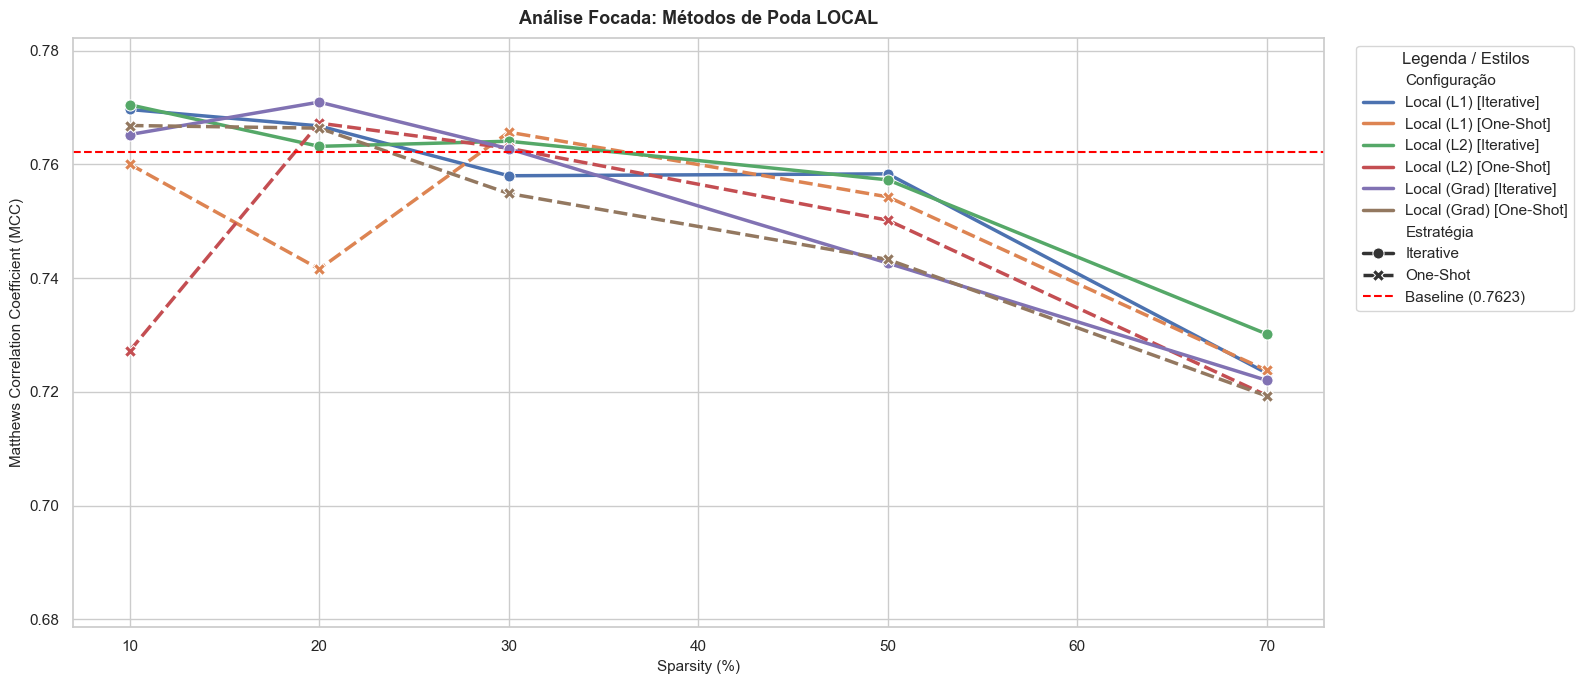

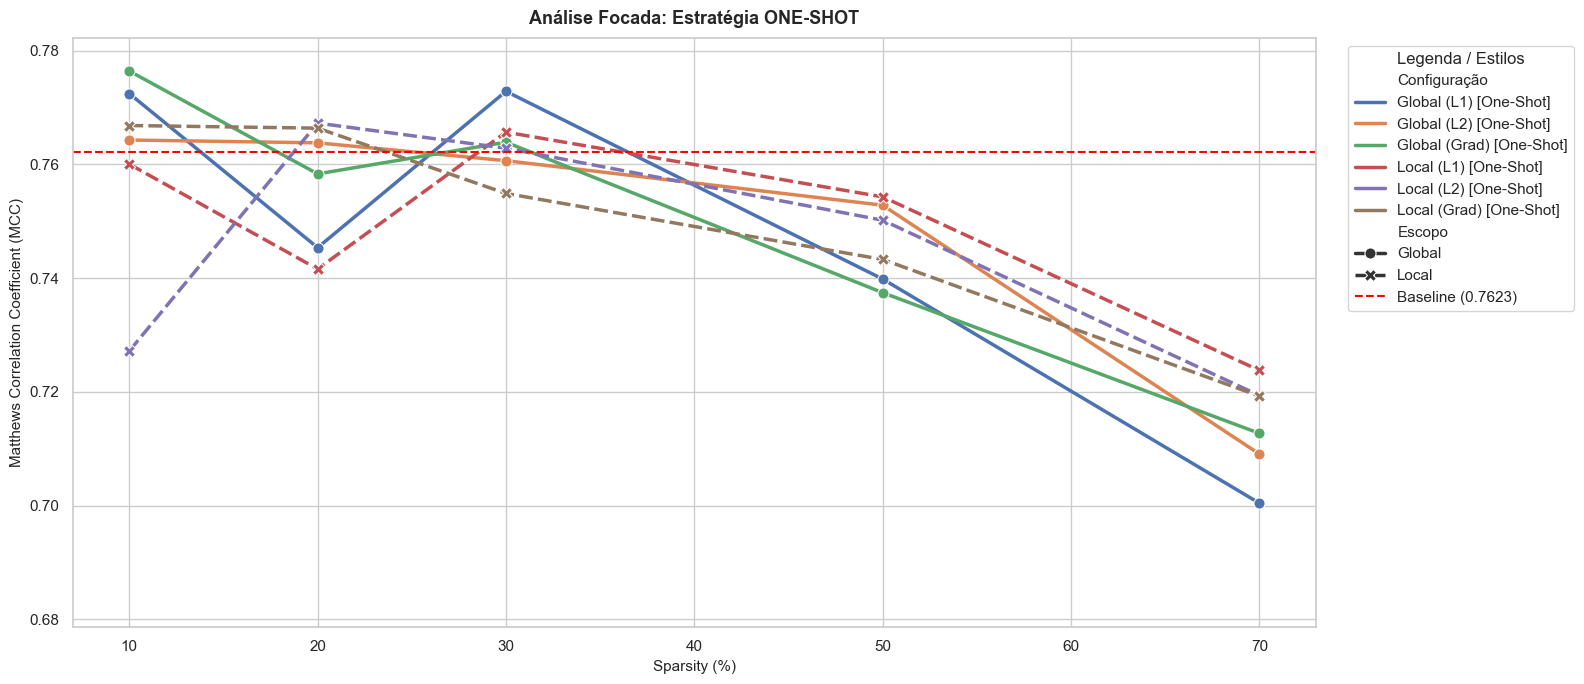

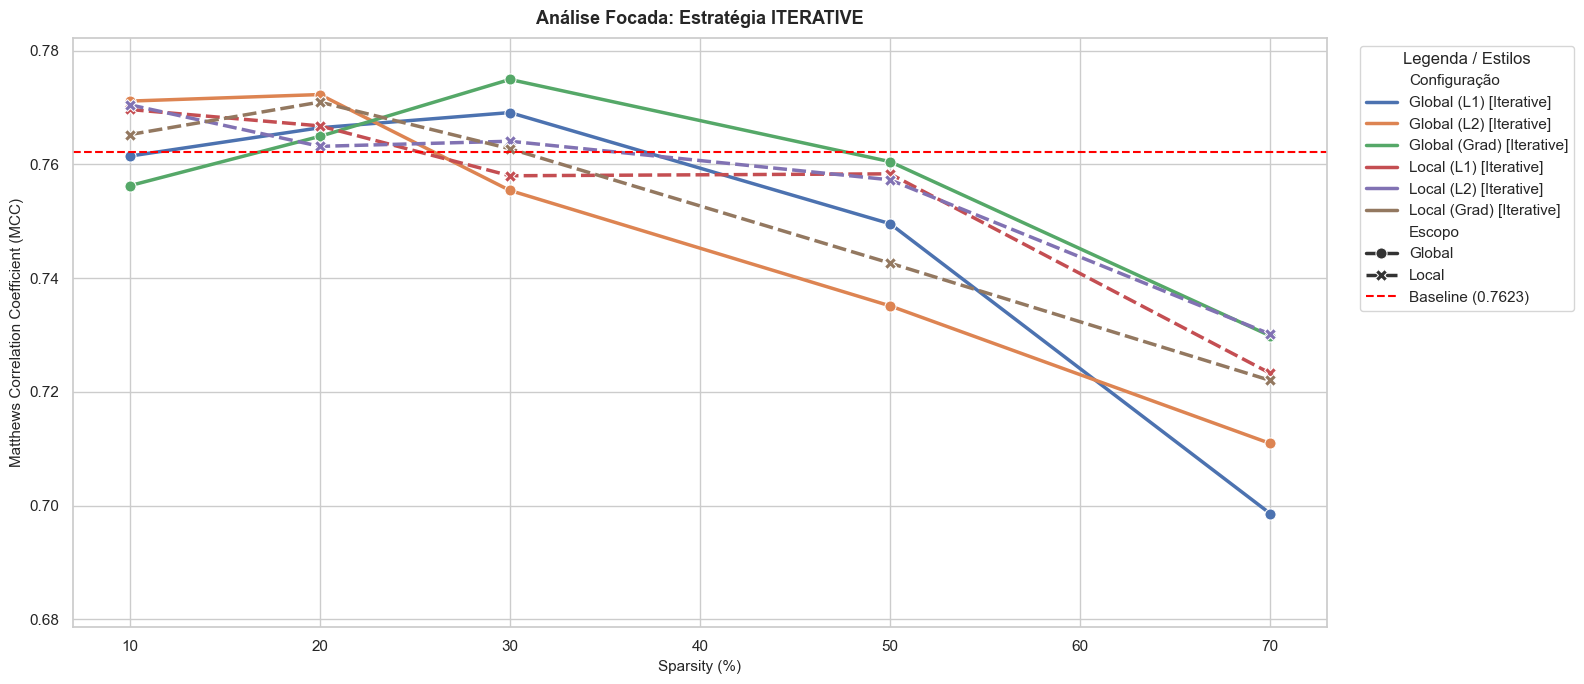

In [43]:
# 1. Recolha rápida dos dados dos checkpoints
save_dir = Path('modelos_podados_vgg')
dados_grafico = []

# Guardar o MCC e a precisão do baseline se existirem
baseline_mcc = baseline_results.get('mcc', None) if 'baseline_results' in locals() or 'baseline_results' in globals() else None
baseline_acc = baseline_results.get('accuracy', 0) if 'baseline_results' in locals() or 'baseline_results' in globals() else None

# Caso o dicionário do baseline use outra designação ou queiras extrair diretamente do df_resultados anterior:
if baseline_mcc is None and 'df_resultados' in locals():
    baseline_mcc = df_resultados[df_resultados['Método'] == 'Baseline']['MCC'].values[0] if 'MCC' in df_resultados.columns else None

checkpoint_files = sorted(list(save_dir.glob('**/*.pt')))
for model_path in checkpoint_files:
    try:
        checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
        post = checkpoint.get('metrics', {})
        
        escopo = model_path.parent.parent.name     # Ex: Global ou Local
        norma = model_path.parent.name             # Ex: L1, L2 ou Taylor
        stem = model_path.stem                     # Ex: VGG_one-shot_10pct
        
        match = re.match(r"VGG_(.+)_(\d+)pct", stem)
        if match:
            estrategia = match.group(1)            # Ex: one-shot ou iterative
            sparsity_pct = int(match.group(2))
            
            # Formatação para capitular os nomes e deixar a legenda bonita
            estrategia_formatada = "One-Shot" if estrategia.lower() == "one-shot" else "Iterative"
            escopo_formatado = "Global" if escopo.lower() == "global" else "Local"
            
            sufixo = "(Grad)" if "Taylor" in norma else f"({norma})"
            config_name = f"{escopo_formatado} {sufixo} [{estrategia_formatada}]"
            
            dados_grafico.append({
                "Configuração": config_name,
                "Escopo": escopo_formatado,
                "Estratégia": estrategia_formatada,
                "Sparsity (%)": sparsity_pct,
                "MCC": post.get('mcc', 0),
                "Compressão (x)": baseline_results['param_count'] / post['param_count'] if baseline_acc else 1
            })
    except Exception:
        continue

df_plot = pd.DataFrame(dados_grafico)

# Ajuste automático do limite inferior do gráfico com base nos dados reais de MCC
min_mcc_detectado = df_plot['MCC'].min() if not df_plot.empty else 0.60
# Define um patamar mínimo para o gráfico não achatar as curvas (usa o menor valor ou 0.65 por segurança)
limite_inferior_y = max(0.50, min_mcc_detectado - 0.02)
limite_superior_y = (baseline_mcc + 0.02) if baseline_mcc else 0.82

# ==============================================================================
# GRÁFICO 1: VISÃO GERAL (TODOS OS MÉTODOS)
# ==============================================================================
plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=df_plot, 
    x="Sparsity (%)", 
    y="MCC",
    hue="Configuração", 
    marker="o", 
    linewidth=2.5,
    markersize=8
)

if baseline_mcc is not None:
    plt.axhline(y=baseline_mcc, color='red', linestyle='--', linewidth=1.5, label=f'Baseline (Original MCC: {baseline_mcc:.4f})')

plt.title("Impacto da Poda Estruturada: Visão Geral (Estabilidade baseada em MCC)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Sparsity (%) — Quanto maior, mais pequeno é o modelo", fontsize=12)
plt.ylabel("Matthews Correlation Coefficient (MCC)", fontsize=12)
plt.ylim(limite_inferior_y, limite_superior_y) 
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Métodos de Poda")
plt.tight_layout()
plt.show()


# ==============================================================================
# GRÁFICOS ANALÍTICOS COM DISTINÇÃO DE TIPO DE LINHA (DASHES)
# ==============================================================================
analises_especificas = [
    {
        "titulo": "Análise Focada: Métodos de Poda GLOBAL", 
        "coluna_filtro": "Escopo", "valor_filtro": "Global", 
        "coluna_estilo": "Estratégia"  
    },
    {
        "titulo": "Análise Focada: Métodos de Poda LOCAL", 
        "coluna_filtro": "Escopo", "valor_filtro": "Local", 
        "coluna_estilo": "Estratégia"  
    },
    {
        "titulo": "Análise Focada: Estratégia ONE-SHOT", 
        "coluna_filtro": "Estratégia", "valor_filtro": "One-Shot", 
        "coluna_estilo": "Escopo"      
    },
    {
        "titulo": "Análise Focada: Estratégia ITERATIVE", 
        "coluna_filtro": "Estratégia", "valor_filtro": "Iterative", 
        "coluna_estilo": "Escopo"      
    }
]

print(f"\n{'='*80}\nDESDOBRAMENTO DAS ANÁLISES ESPECÍFICAS (EIXO Y: MCC)\n{'='*80}")

for analise in analises_especificas:
    df_sub = df_plot[df_plot[analise["coluna_filtro"]] == analise["valor_filtro"]]
    
    if df_sub.empty:
        print(f"\n[Aviso] Sem dados disponíveis para renderizar: {analise['titulo']}")
        continue
        
    plt.figure(figsize=(16, 7))
    
    sns.lineplot(
        data=df_sub, 
        x="Sparsity (%)", 
        y="MCC",
        hue="Configuração", 
        style=analise["coluna_estilo"],  
        markers=True,                    
        linewidth=2.5,
        markersize=8
    )
    
    if baseline_mcc is not None:
        plt.axhline(y=baseline_mcc, color='red', linestyle='--', linewidth=1.5, label=f'Baseline ({baseline_mcc:.4f})')
        
    plt.title(analise["titulo"], fontsize=13, fontweight='bold', pad=10)
    plt.xlabel("Sparsity (%)", fontsize=11)
    plt.ylabel("Matthews Correlation Coefficient (MCC)", fontsize=11)
    plt.ylim(limite_inferior_y, limite_superior_y) 
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Legenda / Estilos")
    plt.tight_layout()
    plt.show()

In [41]:
# ==============================================================================
# CONFIGURAÇÃO DE TOLERÂNCIA
# ==============================================================================
# Mantemos o filtro inicial pela Accuracy, mas expandimos a análise total
tolerancia_maxima_acc = 0.02

# Extração segura das métricas de referência do Baseline
if 'baseline_results' in locals() or 'baseline_results' in globals():
    baseline_acc = baseline_results.get('accuracy', 0)
    baseline_mcc = baseline_results.get('mcc', 0)
    baseline_kappa = baseline_results.get('cohen_kappa', 0)
else:
    baseline_acc = df_resultados[df_resultados['Método'] == 'Baseline']['Accuracy'].values[0] if 'df_resultados' in locals() else None
    baseline_mcc = df_resultados[df_resultados['Método'] == 'Baseline']['MCC'].values[0] if 'df_resultados' in locals() else 0
    baseline_kappa = df_resultados[df_resultados['Método'] == 'Baseline']['Cohen Kappa'].values[0] if 'df_resultados' in locals() else 0

if baseline_acc:
    limite_minimo_accuracy = baseline_acc - tolerancia_maxima_acc
    
    # 1. Filtrar os modelos que passam no teste de estabilidade de Accuracy
    df_filtrado = df_resultados[df_resultados['Accuracy'] >= limite_minimo_accuracy].copy()
    
    # 2. Remover a linha do Baseline para podermos avaliar apenas o ranking dos podados
    df_filtrado = df_filtrado[df_filtrado['Método'] != 'Baseline']
    
    # 3. Ordenar do mais comprimido (mais leve) para o menos comprimido
    df_filtrado = df_filtrado.sort_values(by="Compressão (x)", ascending=False)
    
    print(f"=======================================================================")
    print(f"   RESUMO EXECUTIVO: TOP MODELOS COM ALTA ROBUSTEZ (Tolerância Acc: -{tolerancia_maxima_acc*100}%)")
    print(f"=======================================================================")
    print(f" [Métricas de Referência do Baseline Original]")
    print(f"  -> Accuracy: {baseline_acc:.4f}  |  MCC: {baseline_mcc:.4f}  |  Cohen's Kappa: {baseline_kappa:.4f}\n")
    
    if not df_filtrado.empty:
        # Colunas selecionadas a dedo para o teu relatório final (focado em compressão + robustez)
        colunas_relatorio = [
            "Método", "Sparsity (%)", "Compressão (x)", 
            "Accuracy", "MCC", "Cohen Kappa", 
            "Latência (s)", "VRAM (MB)"
        ]
        
        # Selecionar os top 5 modelos mais leves que não quebraram a performance
        df_top = df_filtrado[colunas_relatorio].head(10)
        
        # Aplicar um estilo visual para realçar os campeões de robustez
        estilo_executivo = df_top.style.set_properties(**{'text-align': 'center'}) \
            .set_table_styles([dict(selector='th', props=[('text-align', 'center')])]) \
            .highlight_max(subset=['MCC', 'Cohen Kappa', 'Compressão (x)'], color='lightgreen') \
            .highlight_min(subset=['Latência (s)'], color='lightcyan') \
            .format({
                "Accuracy": "{:.4f}",
                "MCC": "{:.4f}",
                "Cohen Kappa": "{:.4f}",
                "Latência (s)": "{:.4f}",
                "Compressão (x)": "{:.2f}x"
            })
        
        display(estilo_executivo)
        
        # Pequeno aviso analítico no terminal para te ajudar a decidir
        melhor_mcc_idx = df_top['MCC'].idxmax()
        print(f"Dica de Análise: O modelo podado com maior poder preditivo real (MCC) nesta lista é o \n"
              f"'{df_top.loc[melhor_mcc_idx, 'Método']}' com MCC de {df_top.loc[melhor_mcc_idx, 'MCC']:.4f} "
              f"e uma compressão de {df_top.loc[melhor_mcc_idx, 'Compressão (x)']:.2f}x.")
        
    else:
        print("Nenhum modelo podado conseguiu ficar dentro da tolerância exigida.")
else:
    print("Erro: Não foi possível determinar o 'baseline_acc' para aplicar o filtro.")

   RESUMO EXECUTIVO: TOP MODELOS COM ALTA ROBUSTEZ (Tolerância Acc: -2.0%)
 [Métricas de Referência do Baseline Original]
  -> Accuracy: 0.7852  |  MCC: 0.7623  |  Cohen's Kappa: 0.7613



,Método,Sparsity (%),Compressão (x),Accuracy,MCC,Cohen Kappa,Latência (s),VRAM (MB)
19,Global L2 (Magnitude) (one-shot),50,4.18x,0.7774,0.7528,0.7527,8.2419,3634.490000
44,Local L2 (Magnitude) (iterative),50,4.03x,0.7813,0.7573,0.7570,8.2234,1268.450000
54,Local Taylor (Gradiente) (iterative),50,4.03x,0.7678,0.7426,0.7420,7.9423,2415.590000
34,Local L1 (Magnitude) (iterative),50,4.03x,0.7820,0.7583,0.7578,7.7100,463.600000
39,Local L1 (Magnitude) (one-shot),50,3.99x,0.7784,0.7543,0.7538,7.8315,485.460000
49,Local L2 (Magnitude) (one-shot),50,3.99x,0.7744,0.7502,0.7493,9.0321,758.430000
59,Local Taylor (Gradiente) (one-shot),50,3.99x,0.7676,0.7433,0.7418,8.0852,1767.300000
4,Global L1 (Magnitude) (iterative),50,3.85x,0.7743,0.7496,0.7492,8.1531,3279.390000
24,Global Taylor (Gradiente) (iterative),50,3.19x,0.7839,0.7605,0.7599,9.0944,1476.940000
18,Global L2 (Magnitude) (one-shot),30,2.07x,0.7839,0.7607,0.7599,8.0941,3578.200000


Dica de Análise: O modelo podado com maior poder preditivo real (MCC) nesta lista é o 
'Global L2 (Magnitude) (one-shot)' com MCC de 0.7607 e uma compressão de 2.07x.


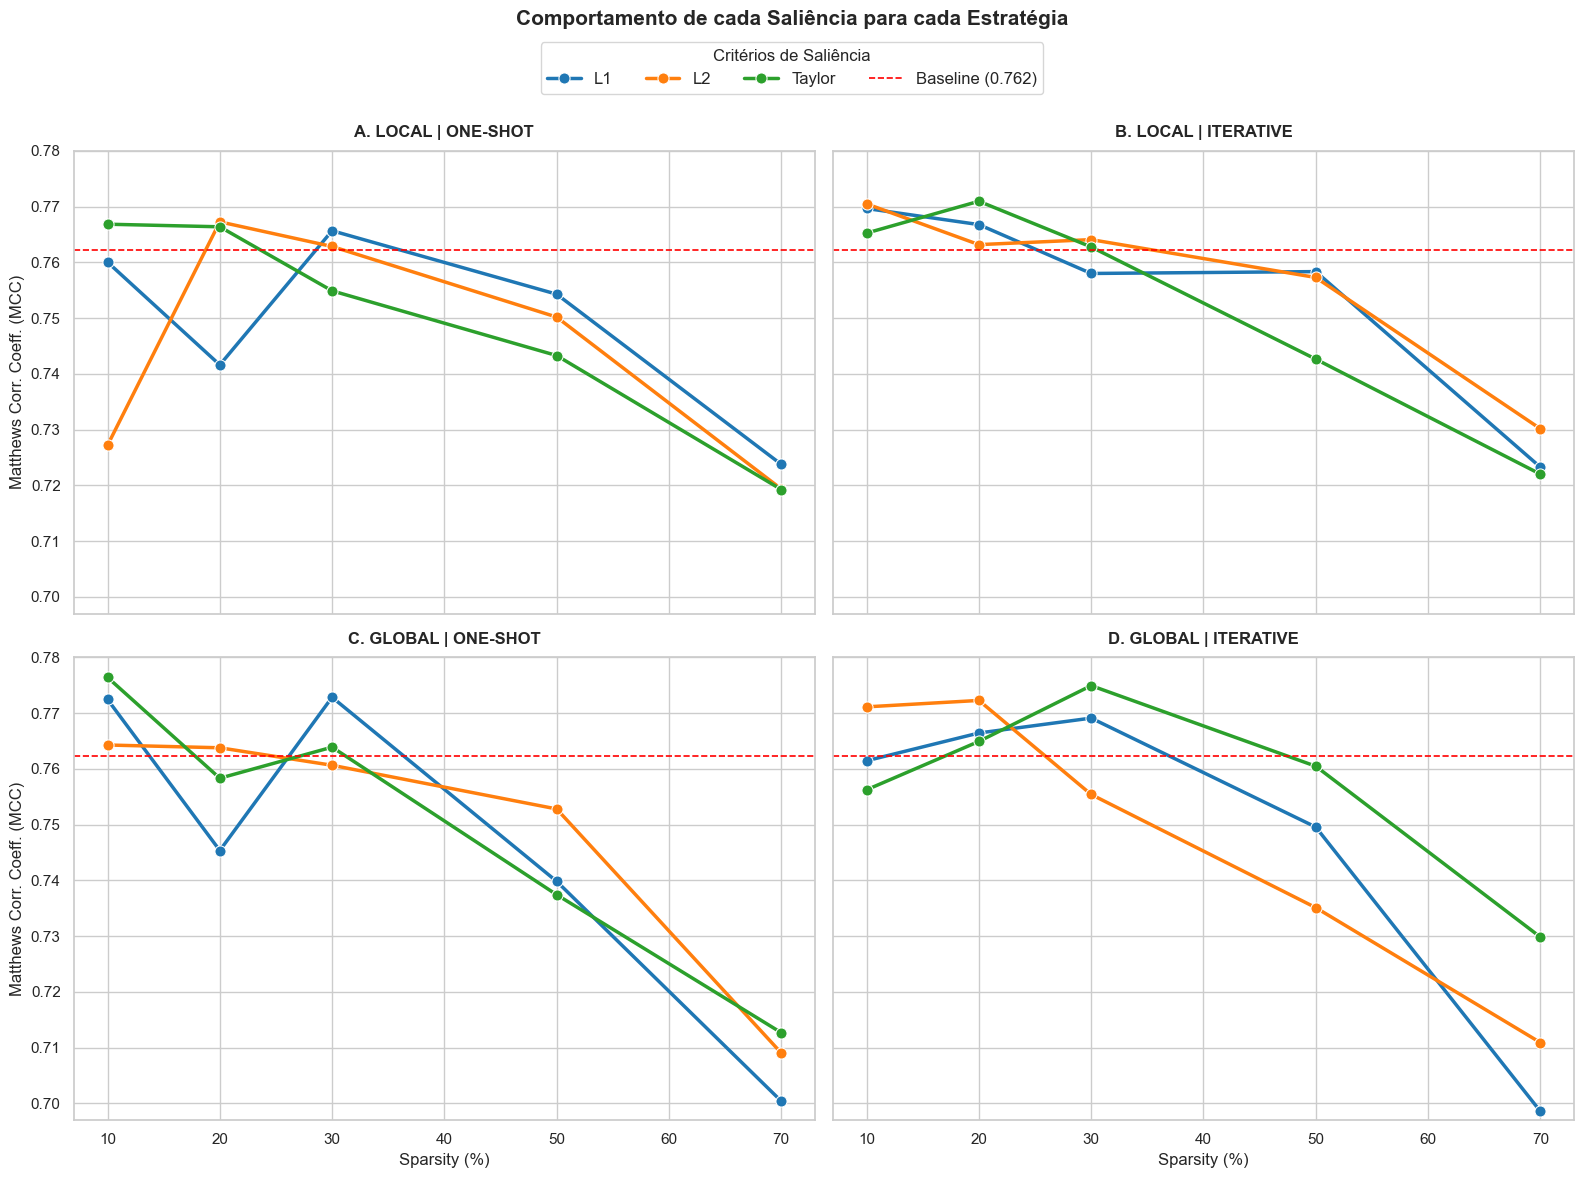

In [35]:
# 1. Recolha detalhada dos dados (incluindo explicitamente a Saliência)
save_dir = Path('modelos_podados_vgg')
dados_analise = []

# Extrair referências do Baseline
baseline_mcc = baseline_results.get('mcc', 0) if 'baseline_results' in locals() or 'baseline_results' in globals() else None
baseline_acc = baseline_results.get('accuracy', 0) if 'baseline_results' in locals() or 'baseline_results' in globals() else None

checkpoint_files = sorted(list(save_dir.glob('**/*.pt')))
for model_path in checkpoint_files:
    try:
        checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
        post = checkpoint.get('metrics', {})
        
        ambito = model_path.parent.parent.name     # Global / Local
        norma = model_path.parent.name             # L1 / L2 / Taylor
        stem = model_path.stem                     # VGG_one-shot_10pct
        
        match = re.match(r"VGG_(.+)_(\d+)pct", stem)
        if match:
            estrategia = match.group(1)            # one-shot / iterative
            sparsity_pct = int(match.group(2))
            
            dados_analise.append({
                "Ambito": ambito,
                "Saliência": norma,                 # L1, L2 ou Taylor
                "Estratégia": estrategia.lower(),   # one-shot ou iterative
                "Sparsity (%)": sparsity_pct,
                "MCC": post.get('mcc', 0),
                "Accuracy": post.get('accuracy', 0)
            })
    except Exception:
        continue

df_saliencia = pd.DataFrame(dados_analise)

# ==============================================================================
# CONSTRUÇÃO DA MATRIZ DE GRÁFICOS 2x2
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
sns.set_theme(style="whitegrid")

# Definição dos quadrantes: (Linha, Coluna) -> (Ambito, Estratégia)
quadrantes = [
    {"ambito": "Local",  "estrategia": "one-shot",  "ax": axes[0, 0], "titulo": "A. LOCAL | ONE-SHOT"},
    {"ambito": "Local",  "estrategia": "iterative", "ax": axes[0, 1], "titulo": "B. LOCAL | ITERATIVE"},
    {"ambito": "Global", "estrategia": "one-shot",  "ax": axes[1, 0], "titulo": "C. GLOBAL | ONE-SHOT"},
    {"ambito": "Global", "estrategia": "iterative", "ax": axes[1, 1], "titulo": "D. GLOBAL | ITERATIVE"}
]

# Palete de cores fixa para garantir que L1, L2 e Taylor mantêm a mesma cor em todos os gráficos
cores_saliencia = {"L1": "#1f77b4", "L2": "#ff7f0e", "Taylor": "#2ca02c"}

for q in quadrantes:
    ax = q["ax"]
    # Filtrar dados para este cenário específico
    df_sub = df_saliencia[
        (df_saliencia["Ambito"].str.lower() == q["ambito"].lower()) & 
        (df_saliencia["Estratégia"] == q["estrategia"])
    ]
    
    if not df_sub.empty:
        # Desenhar as curvas de saliência para este quadrante
        sns.lineplot(
            data=df_sub,
            x="Sparsity (%)",
            y="MCC",
            hue="Saliência",
            palette=cores_saliencia,
            marker="o",
            linewidth=2.5,
            markersize=8,
            ax=ax
        )
    else:
        ax.text(0.5, 0.5, "Sem dados para esta combinação", ha='center', va='center', fontsize=12, color='gray')

    # Linha horizontal do Baseline (A nossa meta perfeita)
    if baseline_mcc is not None:
        ax.axhline(y=baseline_mcc, color='red', linestyle='--', linewidth=1.2, label=f'Baseline ({baseline_mcc:.3f})')
    
    ax.set_title(q["titulo"], fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Sparsity (%)" if ax in axes[1] else "")
    ax.set_ylabel("Matthews Corr. Coeff. (MCC)" if ax in [axes[0, 0], axes[1, 0]] else "")
    ax.set_ylim(0.697, 0.78)
    ax.legend().remove()     # Remove a legenda individual para criar uma unificada limpa

# Criar uma legenda única e elegante para o topo do gráfico
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.96), ncol=4, fontsize=12, title="Critérios de Saliência")

plt.suptitle("Comportamento de cada Saliência para cada Estratégia", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [ ]:
# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle(
    "Análise de Poda Estruturada: Local L1 vs Global L1",
    fontsize=16, fontweight='bold', y=1.02
)

colors = {"Local L1": "#2196F3", "Global L1": "#FF5722"}
markers = {"Local L1": "o", "Global L1": "s"}

baseline_acc = baseline_results['accuracy']
baseline_lat = baseline_results['latency_seconds']
baseline_par = baseline_results['param_count']

# ── Gráfico 1: Sparsity Ratio vs. Test Accuracy ──
ax1 = axes[0]
for method_name, results in all_results.items():
    ratios = [r['sparsity_ratio'] * 100 for r in results]
    accs = [r['post_finetune']['accuracy'] * 100 for r in results]
    ax1.plot(
        ratios, accs,
        marker=markers[method_name],
        color=colors[method_name],
        linewidth=2.5, markersize=9,
        label=method_name
    )

ax1.axhline(
    y=baseline_acc * 100, color='#4CAF50',
    linestyle='--', linewidth=2, alpha=0.8,
    label='Baseline'
)
ax1.set_xlabel('Sparsity Ratio (%)', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title('Degradação de Exatidão', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10, loc='lower left')
ax1.grid(True, alpha=0.3)
ax1.set_xticks([10, 20, 30, 50, 70])

# ── Gráfico 2: Sparsity Ratio vs. Inference Latency ──
ax2 = axes[1]
for method_name, results in all_results.items():
    ratios = [r['sparsity_ratio'] * 100 for r in results]
    lats = [r['post_finetune']['latency_seconds'] for r in results]
    ax2.plot(
        ratios, lats,
        marker=markers[method_name],
        color=colors[method_name],
        linewidth=2.5, markersize=9,
        label=method_name
    )

ax2.axhline(
    y=baseline_lat, color='#4CAF50',
    linestyle='--', linewidth=2, alpha=0.8,
    label='Baseline'
)
ax2.set_xlabel('Sparsity Ratio (%)', fontsize=12)
ax2.set_ylabel('Latência de Inferência (s)', fontsize=12)
ax2.set_title('Redução de Latência', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xticks([10, 20, 30, 50, 70])

# ── Gráfico 3: Compressão de Parâmetros vs. Speedup ──
ax3 = axes[2]
for method_name, results in all_results.items():
    compressions = [
        baseline_par / max(r['post_finetune']['param_count'], 1)
        for r in results
    ]
    speedups = [
        baseline_lat / max(r['post_finetune']['latency_seconds'], 1e-9)
        for r in results
    ]
    ax3.plot(
        compressions, speedups,
        marker=markers[method_name],
        color=colors[method_name],
        linewidth=2.5, markersize=9,
        label=method_name
    )

    # Anotar cada ponto com a sparsity ratio
    for i, r in enumerate(results):
        ax3.annotate(
            f"{r['sparsity_ratio']*100:.0f}%",
            (compressions[i], speedups[i]),
            textcoords="offset points",
            xytext=(8, 5), fontsize=8, alpha=0.7
        )

ax3.axhline(y=1.0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
ax3.axvline(x=1.0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
ax3.set_xlabel('Compressão de Parâmetros (x)', fontsize=12)
ax3.set_ylabel('Speedup (x)', fontsize=12)
ax3.set_title('Compressão vs Speedup', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pruning_analysis_vgg.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nGráficos guardados em: pruning_analysis_vgg.png")

---
## Conclusão

Este notebook implementou e comparou duas estratégias de **Poda Estruturada** num MLP treinado no CIFAR-10:

| Aspeto | Local L1 | Global L1 |
|--------|----------|-----------|
| **Ranking** | Independente por camada | Unificado (rede inteira) |
| **Distribuição** | Uniforme entre camadas | Adaptativa (baseada em importância real) |
| **Flexibilidade** | Previsível | Mais eficiente em preservar capacidade |

### Próximos Passos
- Integrar saliências baseadas em gradientes (Taylor 1ª ordem, OBD) nos hooks definidos
- Aplicar poda iterativa (múltiplas rondas de poda + fine-tuning)
- Testar com arquiteturas convolucionais (VGG, ResNet)